## Setup

In [1]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler, MH_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix,  unif_move, index_ravel_sampler
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_deep= pkl.load(f)

In [3]:
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community = pkl.load(f)

In [4]:
reference = dataset_2community[0][0]
ref_feats = dataset_2community[0][1]

In [5]:
model_deep(ref_feats, reference)

tensor(188.6816, grad_fn=<SqueezeBackward0>)

---

In [6]:
class MySamplerGWG(GWG_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module):
        super().__init__(backend, model)
        self.model = model

    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        return(torch.stack([edges, triangles]))

In [7]:
class MySamplerMH(MH_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module, w_e = 1, w_d = 1):
        super().__init__(backend, model)
        self.model = model
        self.w_e = w_e
        self.w_d = w_d

    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        return(torch.stack([edges, triangles]))

In [8]:
#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class feat_encoded_model(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [9]:
# Initial parameters
betas = torch.tensor([0., 0.])
weight_deep = 1
weight_erg = 1
niter_params = 200000
niter_sampling = 100000
params_update_every = 3
alpha = 0.001
min_change = 0.001

In [10]:
adj_model = feat_encoded_model(model_deep, ref_feats)

sampler = MySamplerGWG(backend="cuda",model = adj_model)
obs = sampler.observables(reference)
print("observed observables: ", obs)
reference = reference.to(device)

CUDA backend not available falling back to cpu
observed observables:  tensor([109., 127.])


In [16]:
params_only_deep = torch.tensor([0., 0.])

observables_deep, graphs_deep = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_only_deep,
                      niter=niter_sampling,
                      save_every=50,
                      burn_in=0.2)

  1%|          | 665/100000 [00:02<05:13, 316.75it/s]


KeyboardInterrupt: 

In [11]:
mean_obs_deep = torch.Tensor([112.2517, 125.7355])

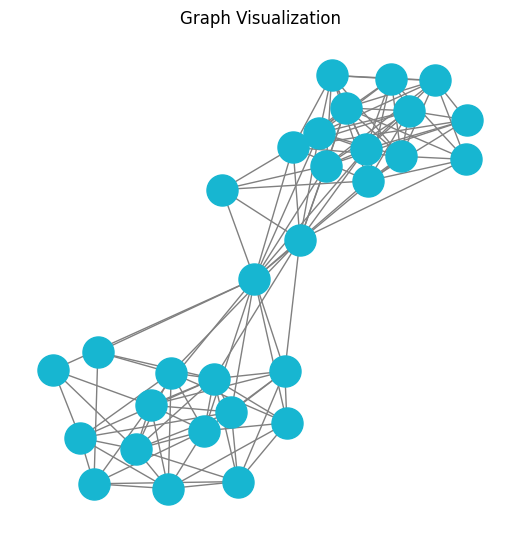

In [13]:
plot_graph(graphs_deep[404])

In [12]:
params, _ = sampler.param_run(graph=reference,
                      observables=obs,
                      params=betas,
                      niter=niter_params,
                      params_update_every=params_update_every,
                      save_every=50,
                      save_params=True,
                      alpha=alpha,
                      min_change=min_change)

  0%|          | 6/200000 [00:00<2:09:22, 25.76it/s]


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

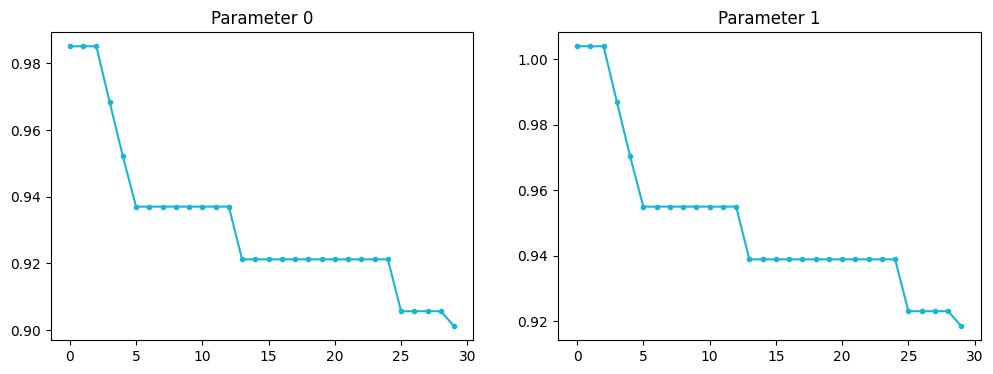

In [19]:
plot_params_iterations(params)

In [15]:
params_for_estimates = torch.stack(params[-100:]).mean(axis = 0)
params_for_estimates

NameError: name 'params' is not defined

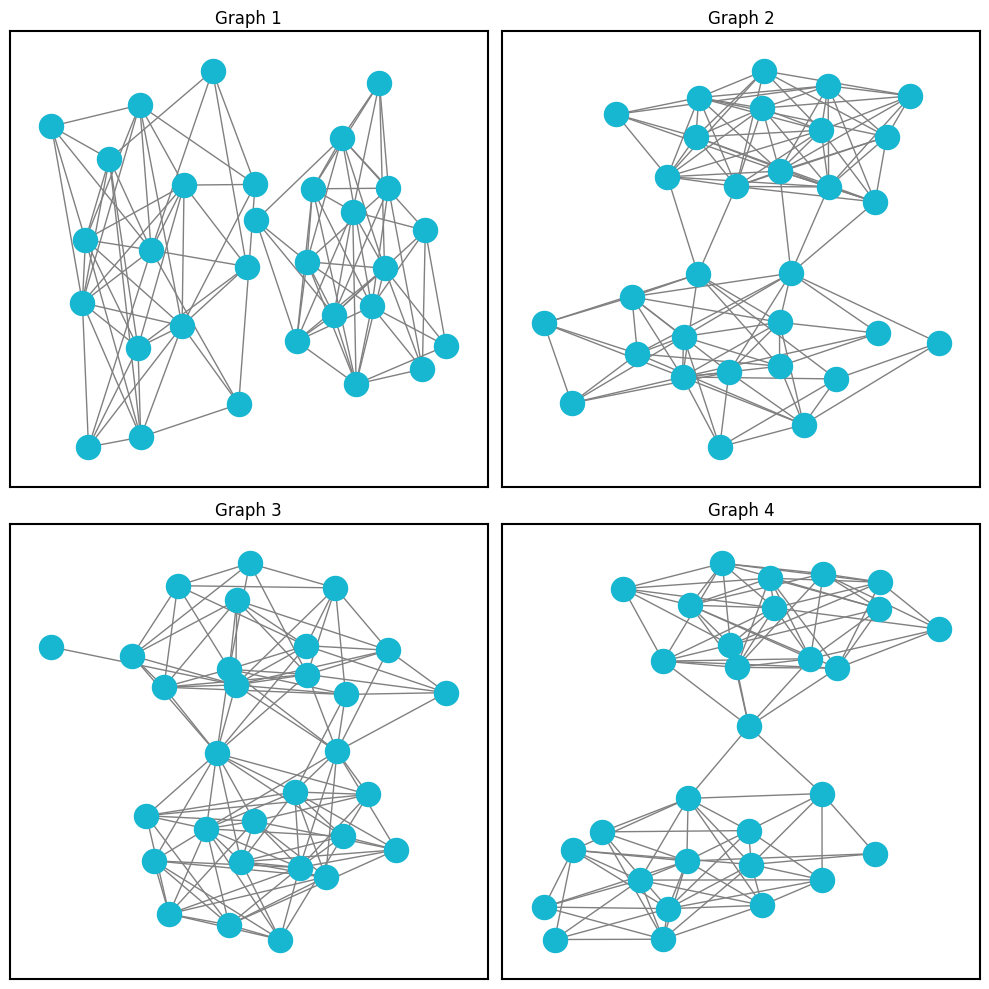

In [ ]:
plot_random_graphs(graphs, 4)

---

In [57]:
energy_sampled = [(params_for_estimates*sampler.observables(g)).sum().item() + model_deep(ref_feats, g).item() for g in graphs]

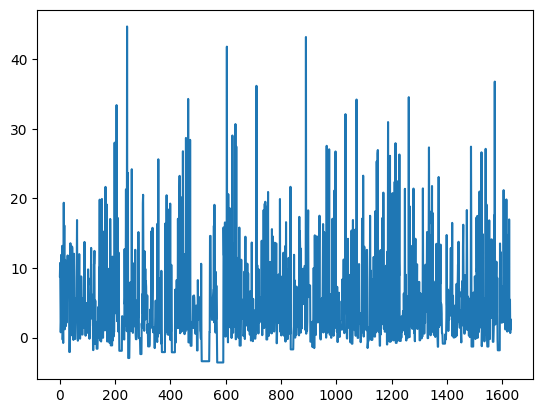

In [58]:
plt.plot(energy_sampled)

## Energy landscape

In [34]:
with open("data/30IEEE_synth_dataset/reduced_30IEEE_synth_list_netX.pkl", "rb") as f:
    netX_30IEEE = pkl.load(f)

with open("data/2community_dataset/2comms_list_netX.pkl", "rb") as f:
    netX_2community  = pkl.load(f)


data1 = GraphDataset(netX_30IEEE)
data2 = GraphDataset(netX_2community)
l1 = [nx.binomial_graph(30, 0.5) for _ in range(100)]
l2 = [nx.binomial_graph(30, 0.1) for _ in range(100)]
l3 = [nx.binomial_graph(30, 0.8) for _ in range(100)]
l4 = [nx.binomial_graph(30, 0.3) for _ in range(100)]
data3 = GraphDataset(l1 + l2 + l3 + l4)

fully_connected_graph = nx.complete_graph(30)

def get_embeddings_mixed(model, params, data1,data2,data3, w_e = 1, w_d = 1):
    complessive_energy = []

    for g in data1:
        adj = g[0]
        feats = g[1]
        energy = model(feats, adj).item()
        erg_energy = (params*sampler.observables(adj)).sum().item()
        energy = energy*w_d + erg_energy*w_e
        complessive_energy.append( (energy, 1) )
    for g in data2:
        adj = g[0]
        feats = g[1]
        energy = model(feats, adj).item()
        erg_energy = (params*sampler.observables(adj)).sum().item()
        energy = energy*w_d + erg_energy*w_e
        complessive_energy.append( (energy, 2) )
    for g in data3:
        adj = g[0]
        feats = g[1]
        energy = model(feats, adj).item()
        erg_energy = (params*sampler.observables(adj)).sum().item()
        energy = energy*w_d + erg_energy*w_e
        complessive_energy.append( (energy, 3) )
    
    return complessive_energy

In [50]:
complessive_energy = get_embeddings_mixed(model_deep, params_for_estimates, data1, data2, data3, w_e=1, w_d=1)

In [47]:
(params_for_estimates*sampler.observables(reference)).sum().item(), model_deep(ref_feats, reference)

(0.0, tensor(188.6816, grad_fn=<SqueezeBackward0>))

In [52]:
with open("log.txt", "a") as f:
    f.write("-----------------------------------------------------------\n")
    f.write(f"reference observables: {sampler.observables(reference)}\n")
    f.write(f"Hyper-params for fitting: \n")
    f.write("Initial parameters = [edges, algebraic connectivity, triangles]\n")
    f.write(f"Initial parameters = {betas}\n")
    f.write(f"weight_ERG = {weight_erg} | weight_deep = {weight_deep}\n")
    f.write(f"niter = {niter_params} | update every {params_update_every} steps\n")
    f.write(f"learning rate = {alpha} | min change = {min_change}\n")
    f.write(f"parameter estimated = {params_for_estimates}")
    f.write("\n")
    f.write(f"Hyper-params for sampling: niters = {niter_sampling}\n")
    f.write(f"Mean observables over samples = {torch.stack(observables).mean(axis = 0)}\n")
    f.write("\n")
    f.write("Energy for reference:\n")
    f.write(f"ERG model: {(params_for_estimates*sampler.observables(reference)).sum().item() }\n")
    f.write(f"Deep model: {model_deep(ref_feats,reference).item()}\n")
    f.write("-----------------------------------------------------------\n")
    f.write("\n\n")
    


In [39]:
def plot_embeddings_hist(complessive_energy, title, bins=30, xlim=None):
    labels_name = {1: "30IEEE", 2: "2community", 3: "Binomial graphs"}
    
    energies_by_label = {1: [], 2: [], 3: []}
    for e, l in complessive_energy:
        energies_by_label[l].append(e)

    colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

    plt.figure(figsize=(8,5))

    for label in [1, 2, 3]:
        data = np.array(energies_by_label[label])
        # density=True → normalizza in modo che l'area sia 1 (per confrontare le forme)
        plt.hist(data, bins=bins, density=True, alpha=0.4, 
                 color=colors[label], label=labels_name[label])
    
    if xlim is not None:
        plt.xlim(xlim)
    plt.xlabel("Model prediction")
    plt.ylabel("Proportion (normalized histogram)")
    plt.title(title)
    plt.legend()
    plt.show()

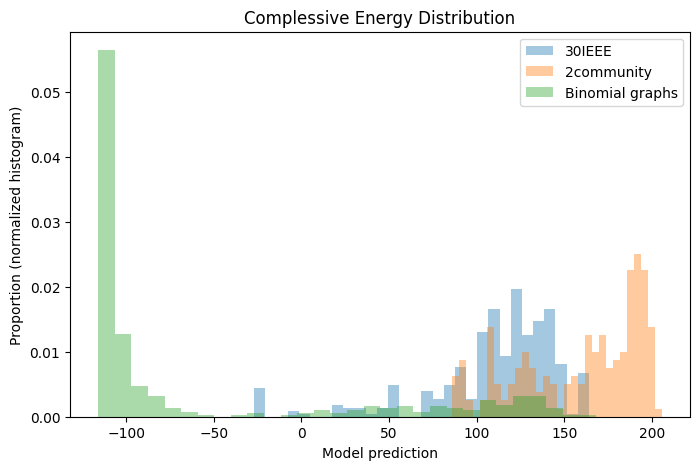

In [51]:
plot_embeddings_hist(complessive_energy, "Complessive Energy Distribution")

---

In [38]:
def gibbs_ministeps2(adj: torch.Tensor, model: nn.Module, node_feats: torch.Tensor, device: torch.device, mini_steps: int) -> torch.Tensor:
    # run `mini_steps` individual mini-steps: sample a random pair each time
    # its formulation is equal to the standard MH one
    n = adj.shape[0]
    A = adj.clone()
    for _ in range(mini_steps):
        i = random.randrange(0, n)
        j = random.randrange(0, n)
        if i == j:
            continue
        a, b = min(i, j), max(i, j)
        A_prime = A.clone()
        A_prime[a, b] = 1.0 - A_prime[a, b]
        A_prime[b, a] = A_prime[a, b]
        with torch.no_grad():
            fA = model(node_feats.to(device), A.to(device))

            fApr = model(node_feats.to(device), A_prime.to(device))

            T = 1
            p = torch.sigmoid((fA - fApr) / T).item()
            
            if random.random() > p:
                #print(f"Accepted change: with delta {fA - fApr} and prob {p}")
                A = A_prime
    return A

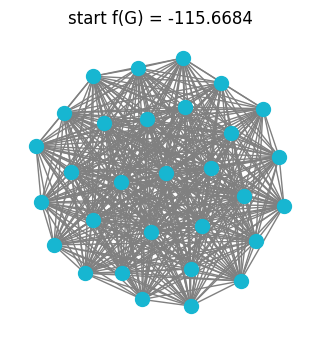

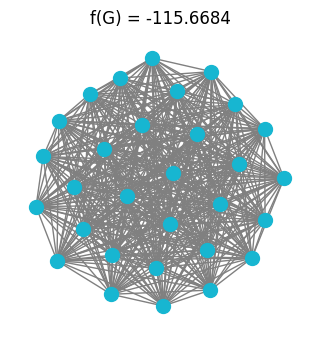

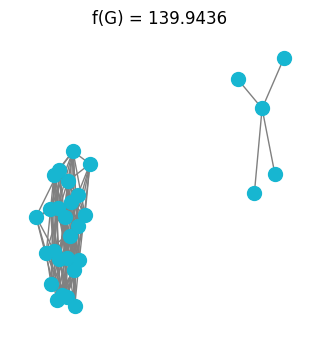

KeyboardInterrupt: 

In [43]:
its = 100000
plot_every = 20000

energies_iterations = []

A, feats = dataset_2community[0]
A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 1)))

energy = model_deep(feats, A)
plot_graph(A, w = 3, h = 3, node_size=100, title=f"start f(G) = {energy:.4f}")

for i in range(its):
    A = gibbs_ministeps(A, model_deep, feats.to(device), device, mini_steps=1)
    energy = model_deep(feats, A)
    if i % plot_every == 0 or i == its - 1:
        plot_graph(A, w = 3, h = 3, node_size=100, title=f"f(G) = {energy:.4f}")
    energies_iterations.append(energy.item())

In [ ]:
plt.plot(energies_iterations)
for i in range(its//plot_every):
    plt.axvline(i*plot_every, color='gray', linestyle='--', linewidth=0.5)

In [ ]:
generated = []
generated_tensors = []

with torch.no_grad():
    for i in range(20):
        A, feats = dataset_2community[i]
        A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 0.5)))
        A_gen = gibbs_ministeps(A, model_deep, feats.to(device), device, mini_steps=1000)
        G_gen = nx.from_numpy_array(A_gen.cpu().numpy())
        generated.append(G_gen)
        generated_tensors.append(torch.tensor(A_gen.cpu().numpy()))

In [ ]:
plot_random_graphs(generated_tensors, 4)